In [9]:
# ============================================================
# CELL 1: Environment Setup
# Notebook location: data/notebooks/
# So ".." goes up to data/
# ============================================================

import os
import sys
import warnings
warnings.filterwarnings("ignore")

# Go up from data/notebooks/ to data/src/
DATA_SRC = os.path.abspath(os.path.join("..", "src"))
if DATA_SRC not in sys.path:
    sys.path.insert(0, DATA_SRC)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot styling
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

# Paths (all relative to data/notebooks/)
DATA_PATH    = os.path.join("..", "framingham.csv")
REPORTS_DIR  = os.path.join("..", "reports")
MODELS_DIR   = os.path.join("..", "models")
SCALER_PATH  = os.path.join("..", "models", "scaler.pkl")
PROCESSED_CSV = os.path.join("..", "framingham_processed.csv")

# Create output folders if they don't exist
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

print("[✓] Python version:", sys.version.split()[0])
print("[✓] Data path:     ", os.path.abspath(DATA_PATH))
print("[✓] Reports dir:   ", os.path.abspath(REPORTS_DIR))
print("[✓] Models dir:    ", os.path.abspath(MODELS_DIR))
print("[✓] DATA_SRC added to sys.path:", DATA_SRC)


[✓] Python version: 3.10.0
[✓] Data path:      e:\Cardionova\data\framingham.csv
[✓] Reports dir:    e:\Cardionova\data\reports
[✓] Models dir:     e:\Cardionova\data\models
[✓] DATA_SRC added to sys.path: e:\Cardionova\data\src


  CARDIONOVA — FRAMINGHAM DATASET OVERVIEW

  Rows (patients): 4240
  Columns:         16

  Column names:
  ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']

  CVD cases  (TenYearCHD = 1): 644
  No CVD     (TenYearCHD = 0): 3596
  CVD Prevalence: 15.19%

  Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.43,0.50,0.00,0.00,0.0,1.00,1.0
age,4240.0,49.58,8.57,32.00,42.00,49.0,56.00,70.0
education,4135.0,1.98,1.02,1.00,1.00,2.0,3.00,4.0
currentSmoker,4240.0,0.49,0.50,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4211.0,9.01,11.92,0.00,0.00,0.0,20.00,70.0
BPMeds,4187.0,0.03,0.17,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4240.0,0.01,0.08,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4240.0,0.31,0.46,0.00,0.00,0.0,1.00,1.0
diabetes,4240.0,0.03,0.16,0.00,0.00,0.0,0.00,1.0
totChol,4190.0,236.70,44.59,107.00,206.00,234.0,263.00,696.0


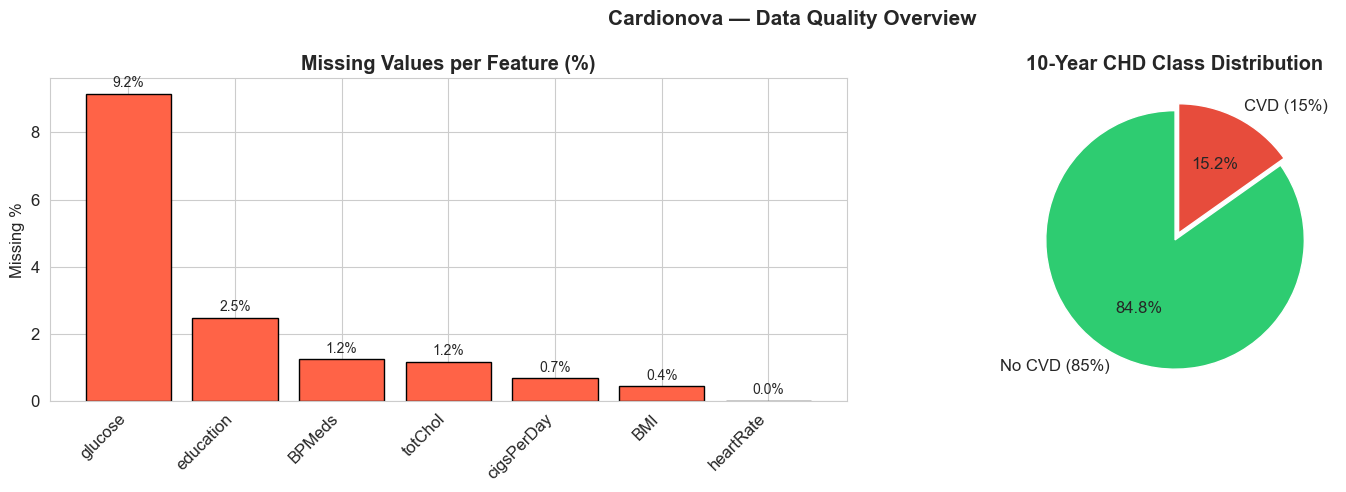

[✓] Saved: reports/01_basic_eda.png


In [10]:
# ============================================================
# CELL 2: Basic EDA
# Goal: Understand what is in framingham.csv
# ============================================================

df_raw = pd.read_csv(DATA_PATH)

print("=" * 55)
print("  CARDIONOVA — FRAMINGHAM DATASET OVERVIEW")
print("=" * 55)
print(f"\n  Rows (patients): {df_raw.shape[0]}")
print(f"  Columns:         {df_raw.shape[1]}")
print(f"\n  Column names:\n  {list(df_raw.columns)}")

print(f"\n  CVD cases  (TenYearCHD = 1): {df_raw['TenYearCHD'].sum()}")
print(f"  No CVD     (TenYearCHD = 0): {(df_raw['TenYearCHD']==0).sum()}")
print(f"  CVD Prevalence: {df_raw['TenYearCHD'].mean():.2%}")

print("\n  Summary Statistics:")
display(df_raw.describe().T.round(2))

# ---- Plot 1: Missing values ----
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

missing_pct = (df_raw.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

bars = axes[0].bar(missing_pct.index, missing_pct.values, color="tomato", edgecolor="black")
axes[0].set_title("Missing Values per Feature (%)", fontweight="bold")
axes[0].set_ylabel("Missing %")
axes[0].set_xticklabels(missing_pct.index, rotation=45, ha="right")
for bar, val in zip(bars, missing_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f"{val:.1f}%", ha="center", fontsize=10)

# ---- Plot 2: CVD class balance ----
cvd_counts = df_raw["TenYearCHD"].value_counts()
axes[1].pie(
    cvd_counts,
    labels=["No CVD (85%)", "CVD (15%)"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2ecc71", "#e74c3c"],
    explode=(0, 0.06),
)
axes[1].set_title("10-Year CHD Class Distribution", fontweight="bold")

plt.suptitle("Cardionova — Data Quality Overview", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "01_basic_eda.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"[✓] Saved: reports/01_basic_eda.png")


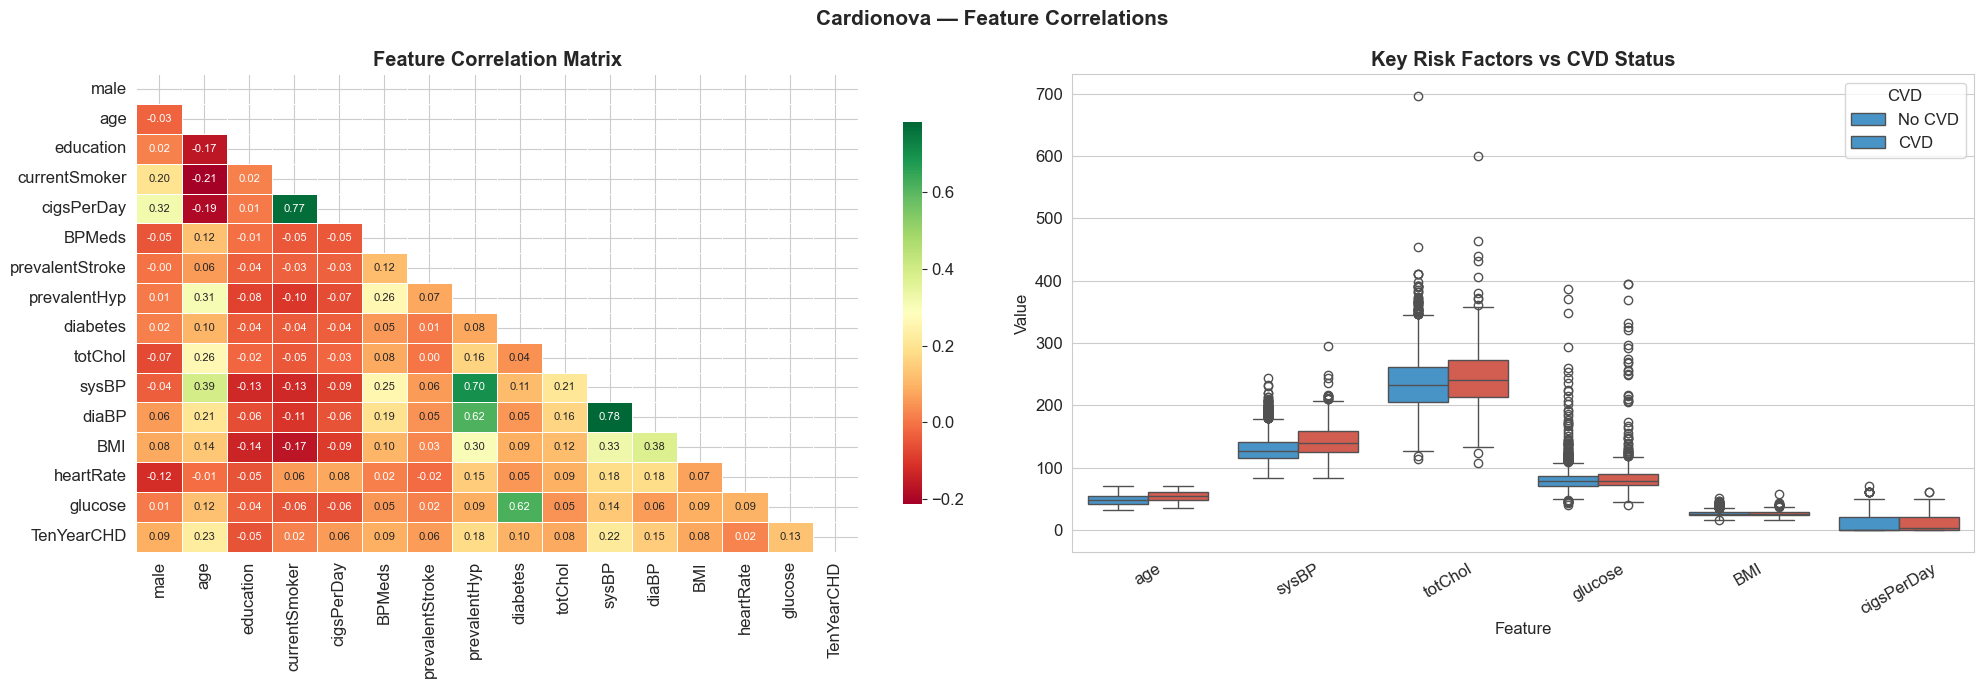

[✓] Saved: reports/02_correlation_risk_factors.png

  Feature vs TenYearCHD (sorted by |r|):
  Feature                    r      p-value   Sig
  --------------------------------------------------
  age                  +0.234       0.0000   ***
  sysBP                +0.223       0.0000   ***
  prevalentHyp         +0.181       0.0000   ***
  diaBP                +0.150       0.0000   ***
  glucose              +0.122       0.0000   ***
  diabetes             +0.093       0.0000   ***
  male                 +0.092       0.0000   ***
  totChol              +0.091       0.0000   ***
  BPMeds               +0.089       0.0000   ***
  BMI                  +0.082       0.0000   ***
  education            -0.063       0.0001   ***
  cigsPerDay           +0.052       0.0016   **
  prevalentStroke      +0.048       0.0034   **
  heartRate            +0.021       0.2148   ns
  currentSmoker        +0.019       0.2465   ns


In [11]:
# ============================================================
# CELL 3: Feature Correlations + Risk Factor Analysis
# Goal: See which raw features relate most to CVD
# ============================================================

numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

# ---- Plot 1: Correlation heatmap ----
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

corr = df_raw[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="RdYlGn",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8},
)
axes[0].set_title("Feature Correlation Matrix", fontweight="bold")

# ---- Plot 2: Key risk factors vs CVD (boxplot) ----
risk_features = ["age", "sysBP", "totChol", "glucose", "BMI", "cigsPerDay"]
df_melt = df_raw[risk_features + ["TenYearCHD"]].melt(
    id_vars="TenYearCHD", var_name="Feature", value_name="Value"
)
sns.boxplot(
    data=df_melt,
    x="Feature",
    y="Value",
    hue="TenYearCHD",
    palette={0: "#3498db", 1: "#e74c3c"},
    ax=axes[1],
)
axes[1].set_title("Key Risk Factors vs CVD Status", fontweight="bold")
axes[1].legend(title="CVD", labels=["No CVD", "CVD"])
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Cardionova — Feature Correlations", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "02_correlation_risk_factors.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[✓] Saved: reports/02_correlation_risk_factors.png")

# ---- Point-biserial correlation with target ----
print("\n  Feature vs TenYearCHD (sorted by |r|):")
print(f"  {'Feature':<20} {'r':>7}   {'p-value':>10}   Sig")
print("  " + "-" * 50)

df_clean = df_raw.dropna()
results = []
for col in numeric_cols:
    if col == "TenYearCHD":
        continue
    r, p = stats.pointbiserialr(df_clean[col], df_clean["TenYearCHD"])
    results.append((col, r, p))

results.sort(key=lambda x: abs(x[1]), reverse=True)
for col, r, p in results:
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"  {col:<20} {r:>+.3f}   {p:>10.4f}   {sig}")


In [12]:
# ============================================================
# CELL 4: Run FraminghamPreProcessor
# Goal: Impute → Engineer Features → Split → Scale → Save
# ============================================================

from preprocessing import FraminghamPreProcessor

print("Importing FraminghamPreProcessor from:", DATA_SRC)

processor = FraminghamPreProcessor(
    n_neighbors=5,        # KNN uses 5 similar patients to fill missing values
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # for reproducibility
    scaler_path=SCALER_PATH,
)

# This runs the entire pipeline in one call:
# load → impute → engineer_features → split_and_scale → save_scaler
X_train, X_test, y_train, y_test, df_processed = processor.fit_transform(DATA_PATH)

print("\n" + "=" * 55)
print("  PIPELINE SUMMARY")
print("=" * 55)
print(f"  Features used:  {len(processor.feature_names)}")
print(f"  Feature list:   {processor.feature_names}")
print(f"\n  X_train shape:  {X_train.shape}")
print(f"  X_test shape:   {X_test.shape}")
print(f"  y_train CVD %:  {y_train.mean():.2%}")
print(f"  y_test CVD  %:  {y_test.mean():.2%}")

# Show the 6 engineered clinical features
engineered = ["hypertension_stage", "pack_years", "pulse_pressure",
              "cholesterol_risk", "age_group", "bmi_category"]
print("\n  Engineered Feature Summary:")
display(df_processed[engineered].describe().T.round(2))

# Save processed dataframe for later modules (SHAP, model training)
df_processed.to_csv(PROCESSED_CSV, index=False)

print(f"\n[✓] Processed dataset saved → data/framingham_processed.csv")
print(f"[✓] Scaler + Imputer saved  → data/models/scaler.pkl")


Importing FraminghamPreProcessor from: e:\Cardionova\data\src
[LOAD] Shape: 4240 rows × 16 columns
[LOAD] CVD prevalence: 15.19%
[LOAD] Missing values per column (only non-zero):
education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64
[IMPUTE] Total missing values after KNN: 0
[FEATS] Added engineered features. New shape: (4240, 22)
[SPLIT] Train: (3392, 21), Test: (848, 21)
[SPLIT] Train CVD rate: 15.18%, Test CVD rate: 15.21%
[SAVE] Scaler + imputer saved to: ..\models\scaler.pkl

  PIPELINE SUMMARY
  Features used:  21
  Feature list:   ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'hypertension_stage', 'pack_years', 'pulse_pressure', 'cholesterol_risk', 'age_group', 'bmi_category']

  X_train shape:  (3392, 21)
  X_test shape:   (848, 21)
  y_train CVD %:  15.18%
  y_test

,count,mean,std,min,25%,50%,75%,max
hypertension_stage,4240.0,1.52,1.27,0.0,0.0,1.0,3.0,4.0
pack_years,4240.0,21.35,28.67,0.0,0.0,0.0,41.0,201.0
pulse_pressure,4240.0,49.46,14.69,15.0,40.0,47.0,56.0,160.0
cholesterol_risk,4240.0,1.24,0.78,0.0,1.0,1.0,2.0,2.0
age_group,4240.0,1.40,0.93,0.0,1.0,1.0,2.0,3.0
bmi_category,4240.0,1.66,0.71,0.0,1.0,2.0,2.0,3.0



[✓] Processed dataset saved → data/framingham_processed.csv
[✓] Scaler + Imputer saved  → data/models/scaler.pkl


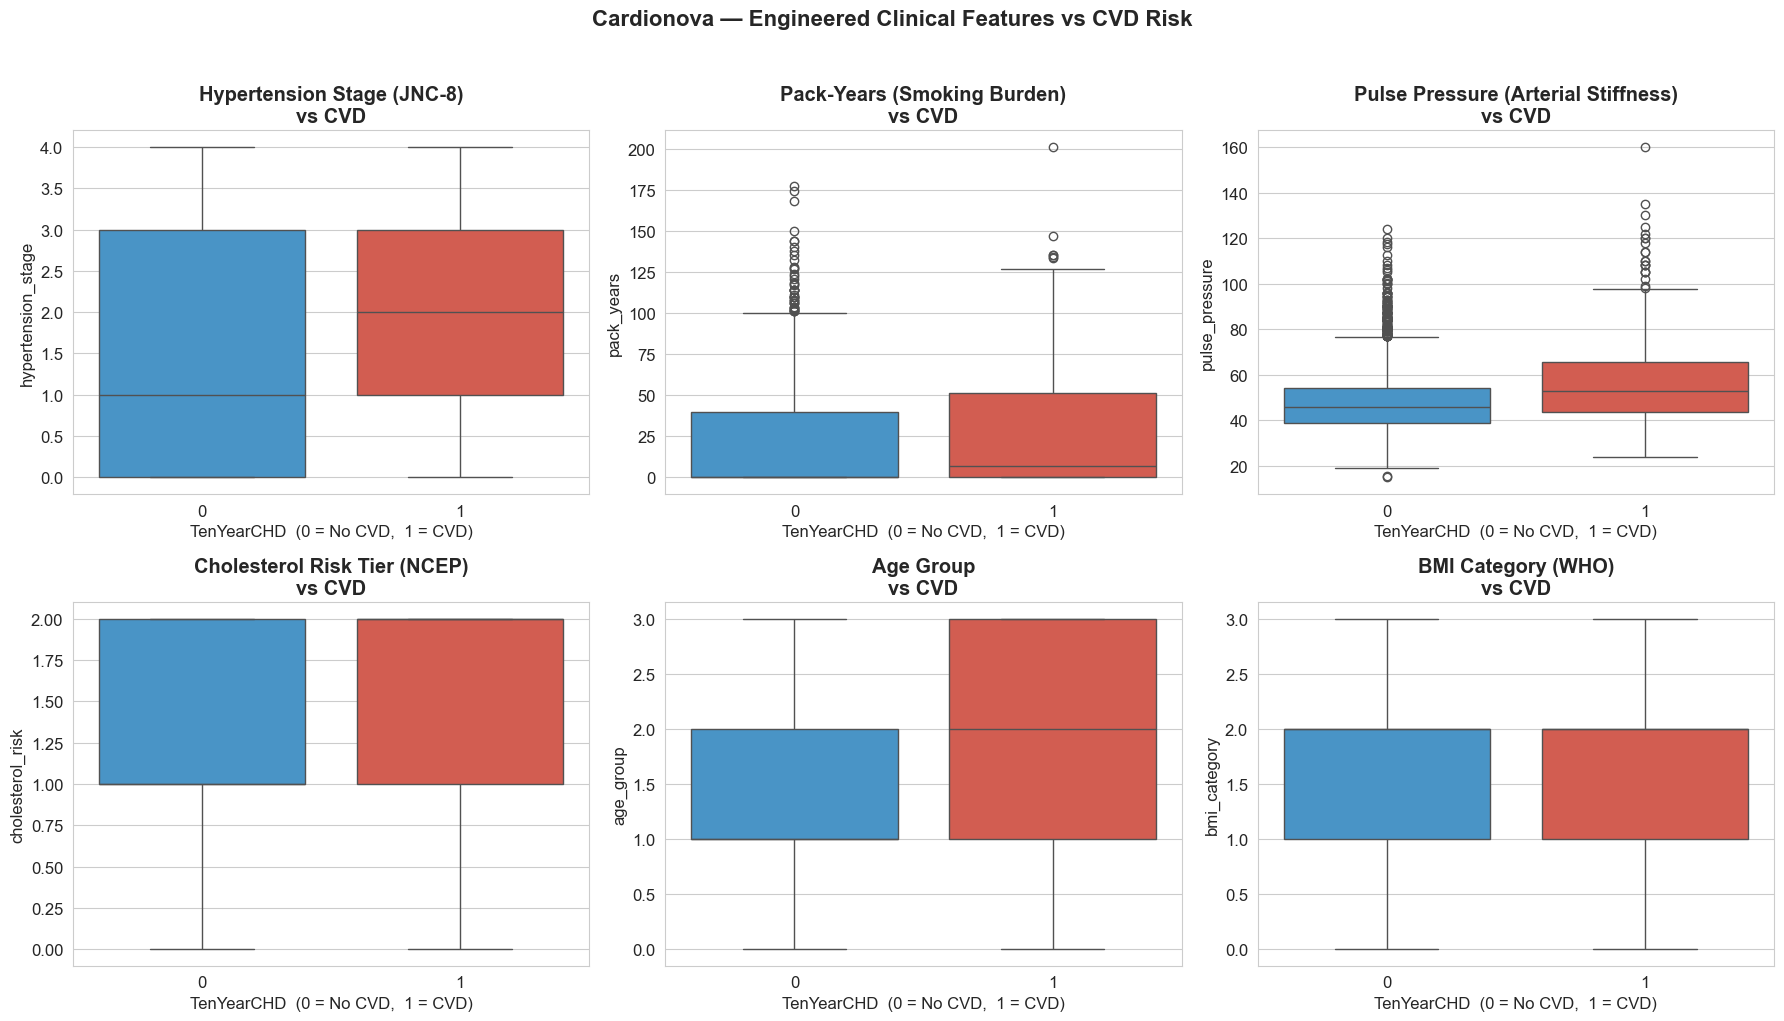

[✓] Saved: reports/03_engineered_features.png


In [13]:
# Fix: Cast to int first
df_processed["TenYearCHD"] = df_processed["TenYearCHD"].astype(int)

engineered = [
    "hypertension_stage", "pack_years", "pulse_pressure",
    "cholesterol_risk",   "age_group",  "bmi_category",
]
titles = [
    "Hypertension Stage (JNC-8)",
    "Pack-Years (Smoking Burden)",
    "Pulse Pressure (Arterial Stiffness)",
    "Cholesterol Risk Tier (NCEP)",
    "Age Group",
    "BMI Category (WHO)",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col, title in zip(axes, engineered, titles):
    sns.boxplot(
        data=df_processed,
        x="TenYearCHD",
        y=col,
        palette=["#3498db", "#e74c3c"],   # ← list, not dict
        ax=ax,
    )
    ax.set_title(f"{title}\nvs CVD", fontweight="bold")
    ax.set_xlabel("TenYearCHD  (0 = No CVD,  1 = CVD)")
    ax.set_ylabel(col)

plt.suptitle("Cardionova — Engineered Clinical Features vs CVD Risk",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "03_engineered_features.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[✓] Saved: reports/03_engineered_features.png")
